In [14]:
# GitHub Copilot 
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras import callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_transformer


# Setup plotting
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('animation', html='html5')


from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

# Load the data, and separate the target
iowa_file_path = 'G:\my_lovely_codes\math_model\day10_machine_learning\input\\train.csv'
home_data = pd.read_csv(iowa_file_path)



X = home_data.copy()
y = X.pop('SalePrice')


features_num = ['LotArea','MSSubClass',
'LotFrontage'
,'OverallQual'
,'OverallCond'
,'YearBuilt',
'YearRemodAdd',
'1stFlrSF',
'2ndFlrSF',
'LowQualFinSF',
'GrLivArea',
'FullBath',
'HalfBath',
'BedroomAbvGr',
'KitchenAbvGr',
'TotRmsAbvGrd',
'Fireplaces',
'WoodDeckSF',
'OpenPorchSF',
'EnclosedPorch',
'3SsnPorch',
'ScreenPorch',
'PoolArea',
'MiscVal',
'MoSold',
'YrSold']
X=X[features_num]

preprocessor = make_column_transformer(
    (StandardScaler(), features_num),
    
)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=42)

scale_factor = 100
X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)
y_train = y_train / scale_factor
y_valid = y_valid / scale_factor

input_shape = [X_train.shape[1]]
print("Input shape: {}".format(input_shape))


Input shape: [26]


In [15]:
X.head()

,LotArea,MSSubClass,LotFrontage,OverallQual,OverallCond,YearBuilt,YearRemodAdd,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,8450,60,65.0,7,5,2003,2003,856,854,0,1710,2,1,3,1,8,0,0,61,0,0,0,0,0,2,2008
1,9600,20,80.0,6,8,1976,1976,1262,0,0,1262,2,0,3,1,6,1,298,0,0,0,0,0,0,5,2007
2,11250,60,68.0,7,5,2001,2002,920,866,0,1786,2,1,3,1,6,1,0,42,0,0,0,0,0,9,2008
3,9550,70,60.0,7,5,1915,1970,961,756,0,1717,1,0,3,1,7,1,0,35,272,0,0,0,0,2,2006
4,14260,60,84.0,8,5,2000,2000,1145,1053,0,2198,2,1,4,1,9,1,192,84,0,0,0,0,0,12,2008


Epoch 1/500


g:\anaconda3\envs\pytorch\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1805.2570 - val_loss: 1785.0485 - learning_rate: 0.0010
Epoch 2/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1827.8253 - val_loss: 1784.4176 - learning_rate: 0.0010
Epoch 3/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1778.6388 - val_loss: 1783.4882 - learning_rate: 0.0010
Epoch 4/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1851.6398 - val_loss: 1782.2452 - learning_rate: 0.0010
Epoch 5/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1787.7318 - val_loss: 1780.5774 - learning_rate: 0.0010
Epoch 6/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1835.4235 - val_loss: 1778.5604 - learning_rate: 0.0010
Epoch 7/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1781.2843 - val_loss: 1776.1149 - learning_rate: 0.0010
Epoch 8/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1831.6844 - val_loss: 1773.3132 - learning_rate: 0.0010
Epoch 9/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1835.0005 - val_loss: 1769.8811 -

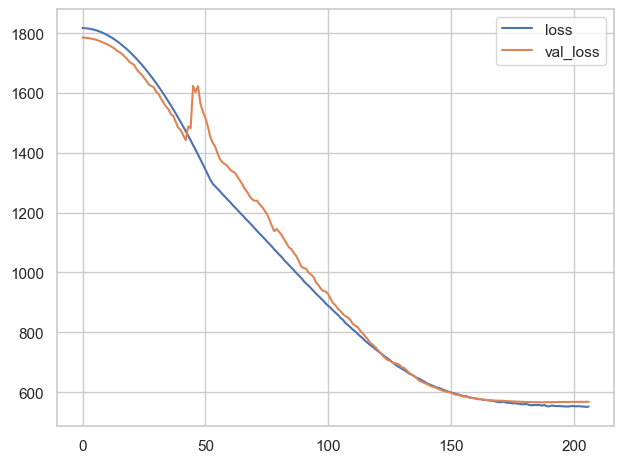

In [26]:
model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=input_shape),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1)
])


early_stopping = callbacks.EarlyStopping(
    patience=20,
    min_delta=0.0005,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)


model.compile(
    optimizer='adam',
    loss='mae',
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=32,
    epochs=500,
     callbacks=[early_stopping, reduce_lr],
    verbose=1
)
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
print("Minimum Validation Loss: {:0.4f}".format(history_df['val_loss'].min()))

XGBoost MAE: 189.9984485766267


In [25]:
# path to file you will use for predictions
test_data_path = '../day10_machine_learning/input/test.csv'

# read test data file using pandas
test_data = pd.read_csv(test_data_path)

# create test_X which comes from test_data but includes only the columns you used for prediction.
# The list of columns is stored in a variable called features
test_X = test_data.loc[:,features_num]

# make predictions which we will submit. 
test_preds = model.predict(test_X).flatten()

# Run the code to save predictions in the format used for competition scoring
scale_factor = 100
output = pd.DataFrame({'Id': test_data.Id,
                       'SalePrice': test_preds* scale_factor})
output.to_csv('submission.csv', index=False)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
